# CCS-230 Final Project: Heart Disease Data Mining

This single notebook contains the complete pipeline:
- Dataset acquisition
- Data cleaning and preparation
- EDA and visualizations
- Association rule mining
- K-Means clustering (patient archetypes)
- Classification (Decision Tree vs Random Forest)
- Model evaluation with recall emphasis
- Report draft and PDF export

In [1]:
# Install dependencies inside the active environment if missing
import sys
import subprocess
import importlib

required_packages = [
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("sklearn", "scikit-learn"),
    ("mlxtend", "mlxtend"),
    ("ucimlrepo", "ucimlrepo"),
    ("reportlab", "reportlab"),
]

for module_name, package_name in required_packages:
    try:
        importlib.import_module(module_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

print("Dependency check complete.")

Dependency check complete.


In [2]:
# Imports and global settings
from pathlib import Path
from textwrap import wrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from mlxtend.frequent_patterns import apriori, association_rules

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    silhouette_score,
)

from reportlab.lib.pagesizes import LETTER
from reportlab.pdfgen import canvas

RANDOM_STATE = 42
project_dir = Path.cwd()
out_dir = project_dir / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print(f"Project directory: {project_dir}")
print(f"Outputs directory: {out_dir}")

Project directory: C:\Users\Ralph\Desktop\DATA MINING final
Outputs directory: C:\Users\Ralph\Desktop\DATA MINING final\outputs


In [3]:
# Step 1: Fetch and save dataset (heart.csv)
heart = fetch_ucirepo(id=45)
features = heart.data.features.copy()
targets = heart.data.targets.copy()

df_raw = pd.concat([features, targets], axis=1)
# Normalize target name and meaning: 0=no disease, 1=disease present
target_col = targets.columns[0]
df_raw = df_raw.rename(columns={target_col: "HeartDisease"})
df_raw["HeartDisease"] = pd.to_numeric(df_raw["HeartDisease"], errors="coerce")
df_raw["HeartDisease"] = (df_raw["HeartDisease"] > 0).astype(int)

df_raw = df_raw.replace("?", np.nan)

dataset_path = project_dir / "heart.csv"
df_raw.to_csv(dataset_path, index=False)

print(f"Saved dataset to: {dataset_path}")
print("Shape:", df_raw.shape)
df_raw.head()

Saved dataset to: C:\Users\Ralph\Desktop\DATA MINING final\heart.csv
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,HeartDisease
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 2) Data Cleaning and EDA

Missing values after cleaning:
age             0
sex             0
cp              0
trestbps        0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
thal            0
HeartDisease    0
dtype: int64


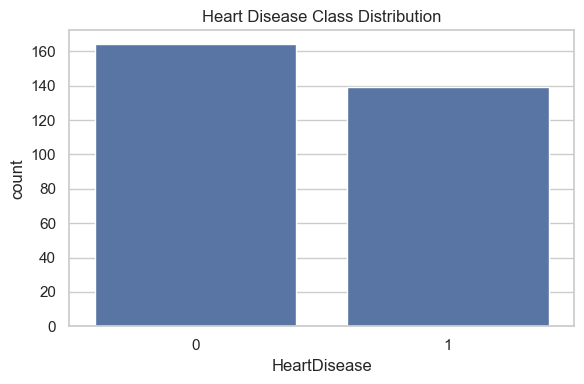

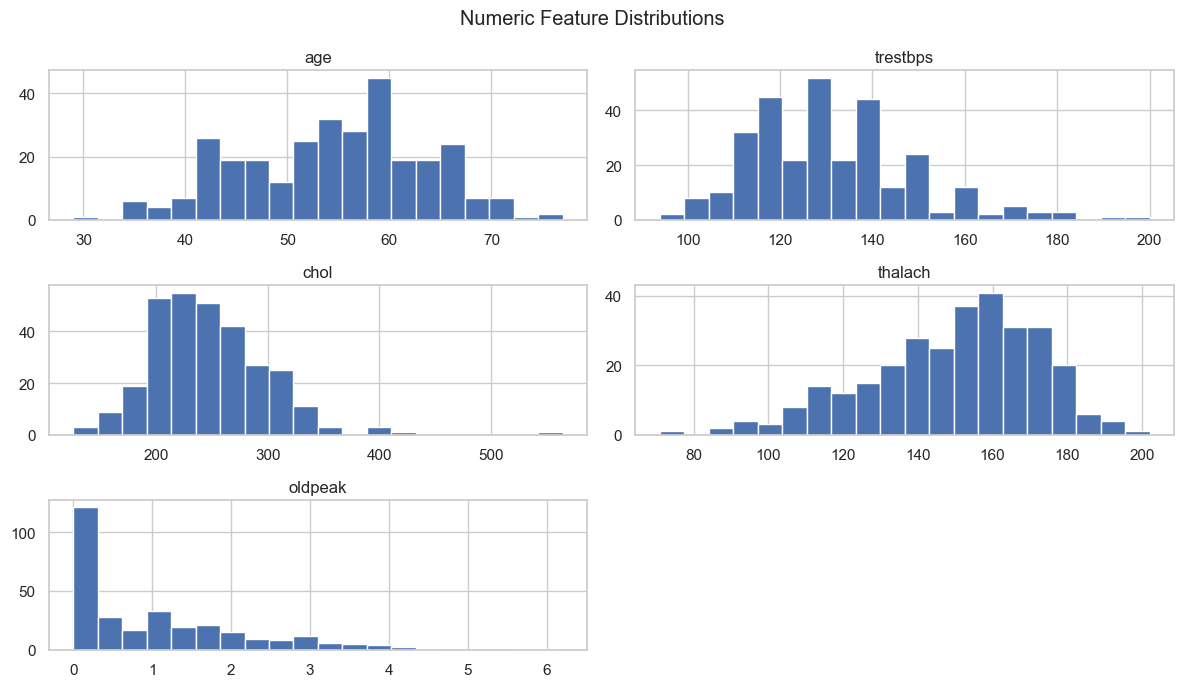

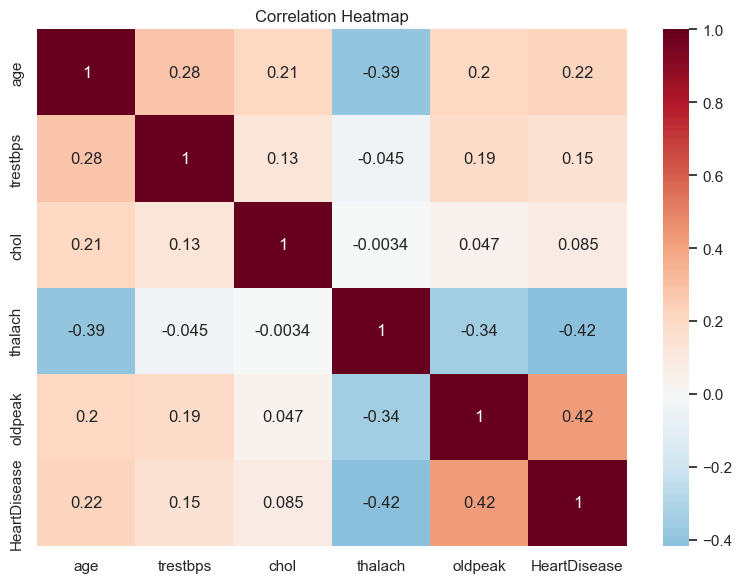

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [4]:
# Clean data and generate EDA outputs

# Numeric coercion for all non-target columns
work_df = df_raw.copy()
for col in work_df.columns:
    if col != "HeartDisease":
        work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

# Median imputation
feature_cols = [c for c in work_df.columns if c != "HeartDisease"]
imputer = SimpleImputer(strategy="median")
work_df[feature_cols] = imputer.fit_transform(work_df[feature_cols])

# Descriptive statistics
desc = work_df.describe(include="all").transpose()
desc.to_csv(out_dir / "descriptive_statistics.csv")

print("Missing values after cleaning:")
print(work_df.isna().sum())

# EDA plot: target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=work_df, x="HeartDisease")
plt.title("Heart Disease Class Distribution")
plt.tight_layout()
plt.savefig(out_dir / "eda_target_distribution.png", dpi=150)
plt.show()

# EDA plots: numeric histograms
numeric_focus = [c for c in ["age", "trestbps", "chol", "thalach", "oldpeak"] if c in work_df.columns]
work_df[numeric_focus].hist(figsize=(12, 7), bins=20)
plt.suptitle("Numeric Feature Distributions")
plt.tight_layout()
plt.savefig(out_dir / "eda_numeric_histograms.png", dpi=150)
plt.show()

# EDA plot: correlation heatmap
plt.figure(figsize=(8, 6))
corr = work_df[numeric_focus + ["HeartDisease"]].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(out_dir / "eda_correlation_heatmap.png", dpi=150)
plt.show()

display(desc.head(15))

## 3) Association Rules and Clustering

Top rules:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2412,"cp=4.0, oldpeak=oldpeak_Q4, thal=7.0",HeartDisease=1,0.115512,0.458746,0.115512,1.000000,2.179856,1.0,0.062521,inf,0.611940,0.251799,1.000000,0.625899
2506,"exang=1.0, oldpeak=oldpeak_Q4, thal=7.0",HeartDisease=1,0.102310,0.458746,0.102310,1.000000,2.179856,1.0,0.055376,inf,0.602941,0.223022,1.000000,0.611511
2429,"cp=4.0, restecg=2.0, thal=7.0",HeartDisease=1,0.135314,0.458746,0.132013,0.975610,2.126689,1.0,0.069939,22.191419,0.612691,0.285714,0.954938,0.631690
2318,"cp=4.0, exang=1.0, oldpeak=oldpeak_Q4",HeartDisease=1,0.125413,0.458746,0.122112,0.973684,2.122491,1.0,0.064580,20.567657,0.604691,0.264286,0.951380,0.619936
4921,"cp=4.0, exang=1.0, slope=2.0, thal=7.0",HeartDisease=1,0.108911,0.458746,0.105611,0.969697,2.113800,1.0,0.055648,17.861386,0.591319,0.228571,0.944013,0.599956
4964,"cp=4.0, fbs=0.0, restecg=2.0, thal=7.0",HeartDisease=1,0.108911,0.458746,0.105611,0.969697,2.113800,1.0,0.055648,17.861386,0.591319,0.228571,0.944013,0.599956
5035,"cp=4.0, restecg=2.0, sex=1.0, thal=7.0",HeartDisease=1,0.108911,0.458746,0.105611,0.969697,2.113800,1.0,0.055648,17.861386,0.591319,0.228571,0.944013,0.599956
2299,"ca=1.0, cp=4.0, sex=1.0",HeartDisease=1,0.105611,0.458746,0.102310,0.968750,2.111736,1.0,0.053862,17.320132,0.588620,0.221429,0.942264,0.595886
4811,"cp=4.0, exang=1.0, fbs=0.0, oldpeak=oldpeak_Q4",HeartDisease=1,0.105611,0.458746,0.102310,0.968750,2.111736,1.0,0.053862,17.320132,0.588620,0.221429,0.942264,0.595886
2451,"cp=4.0, slope=2.0, thal=7.0",HeartDisease=1,0.158416,0.458746,0.151815,0.958333,2.089029,1.0,0.079143,12.990099,0.619437,0.326241,0.923018,0.644634


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,HeartDisease,Count
Cluster,,,,,,,,,,,,,,,
0,51.566038,0.597484,2.723270,129.037736,244.245283,0.132075,0.855346,162.522013,0.069182,0.507547,1.308176,0.333333,3.742138,0.176101,159
1,57.611111,0.770833,3.638889,134.618056,249.395833,0.166667,1.138889,135.347222,0.611111,1.627083,1.923611,1.027778,5.805556,0.770833,144


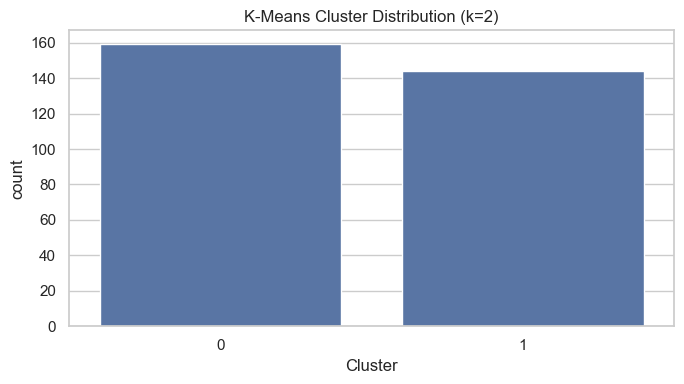

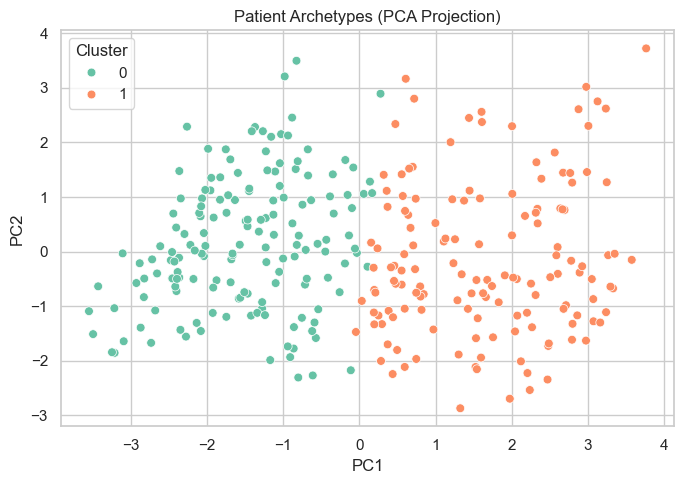

In [5]:
# Association rule mining + K-Means clustering

# ---------- Association rules ----------
trans = work_df.copy()
for col in ["age", "trestbps", "chol", "thalach", "oldpeak"]:
    if col in trans.columns:
        trans[col] = pd.qcut(
            trans[col].rank(method="first"),
            q=4,
            labels=[f"{col}_Q1", f"{col}_Q2", f"{col}_Q3", f"{col}_Q4"],
        )

transaction_df = pd.DataFrame(index=trans.index)
for col in trans.columns:
    tokens = trans[col].astype(str).map(lambda x: f"{col}={x}")
    dummies = pd.get_dummies(tokens)
    transaction_df = pd.concat([transaction_df, dummies], axis=1)

transaction_df = transaction_df.T.groupby(level=0).max().T

freq = apriori(transaction_df.astype(bool), min_support=0.10, use_colnames=True)
if freq.empty:
    freq = apriori(transaction_df.astype(bool), min_support=0.05, use_colnames=True)

rules = association_rules(freq, metric="confidence", min_threshold=0.60)
if rules.empty:
    rules = association_rules(freq, metric="lift", min_threshold=1.05)

rules = rules[rules["consequents"].apply(lambda s: "HeartDisease=1" in s)].copy()
if not rules.empty:
    rules = rules.sort_values(["confidence", "lift"], ascending=False).head(15)
    rules["antecedents"] = rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
    rules["consequents"] = rules["consequents"].apply(lambda s: ", ".join(sorted(s)))

rules.to_csv(out_dir / "top_association_rules.csv", index=False)

print("Top rules:")
display(rules.head(10))

# ---------- Clustering ----------
X_cluster = work_df.drop(columns=["HeartDisease"]).copy()
cluster_cats = [c for c in ["cp", "restecg", "slope", "thal", "ca"] if c in X_cluster.columns]
X_cluster = pd.get_dummies(X_cluster, columns=cluster_cats, drop_first=True)

scaler_cluster = StandardScaler()
Xc_scaled = scaler_cluster.fit_transform(X_cluster)

best_k = None
best_score = -1
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(Xc_scaled)
    score = silhouette_score(Xc_scaled, labels)
    if score > best_score:
        best_score = score
        best_k = k

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
clusters = kmeans.fit_predict(Xc_scaled)

cluster_df = work_df.copy()
cluster_df["Cluster"] = clusters

cluster_profile = cluster_df.groupby("Cluster").mean(numeric_only=True)
cluster_profile["Count"] = cluster_df.groupby("Cluster").size()
cluster_profile.to_csv(out_dir / "cluster_profiles.csv")

display(cluster_profile)

plt.figure(figsize=(7, 4))
sns.countplot(data=cluster_df, x="Cluster")
plt.title(f"K-Means Cluster Distribution (k={best_k})")
plt.tight_layout()
plt.savefig(out_dir / "cluster_distribution.png", dpi=150)
plt.show()

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Xc_scaled)
pca_df = pd.DataFrame({"PC1": coords[:, 0], "PC2": coords[:, 1], "Cluster": clusters})

plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="Set2", s=40)
plt.title("Patient Archetypes (PCA Projection)")
plt.tight_layout()
plt.savefig(out_dir / "cluster_pca_scatter.png", dpi=150)
plt.show()

## 4) Classification, Evaluation, and Report Generation

,model,accuracy,precision,recall,f1
1,Random Forest,0.828947,0.805556,0.828571,0.816901
0,Decision Tree,0.697368,0.730769,0.542857,0.622951


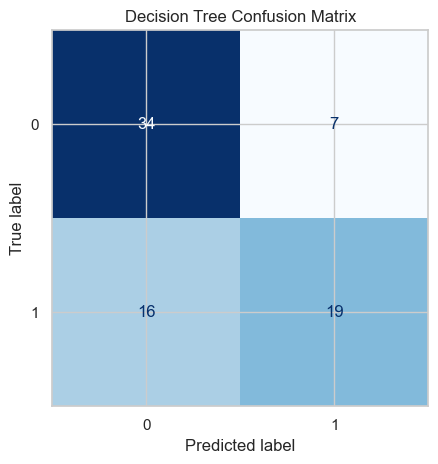

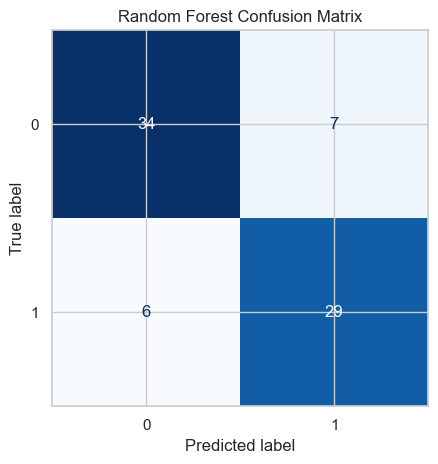

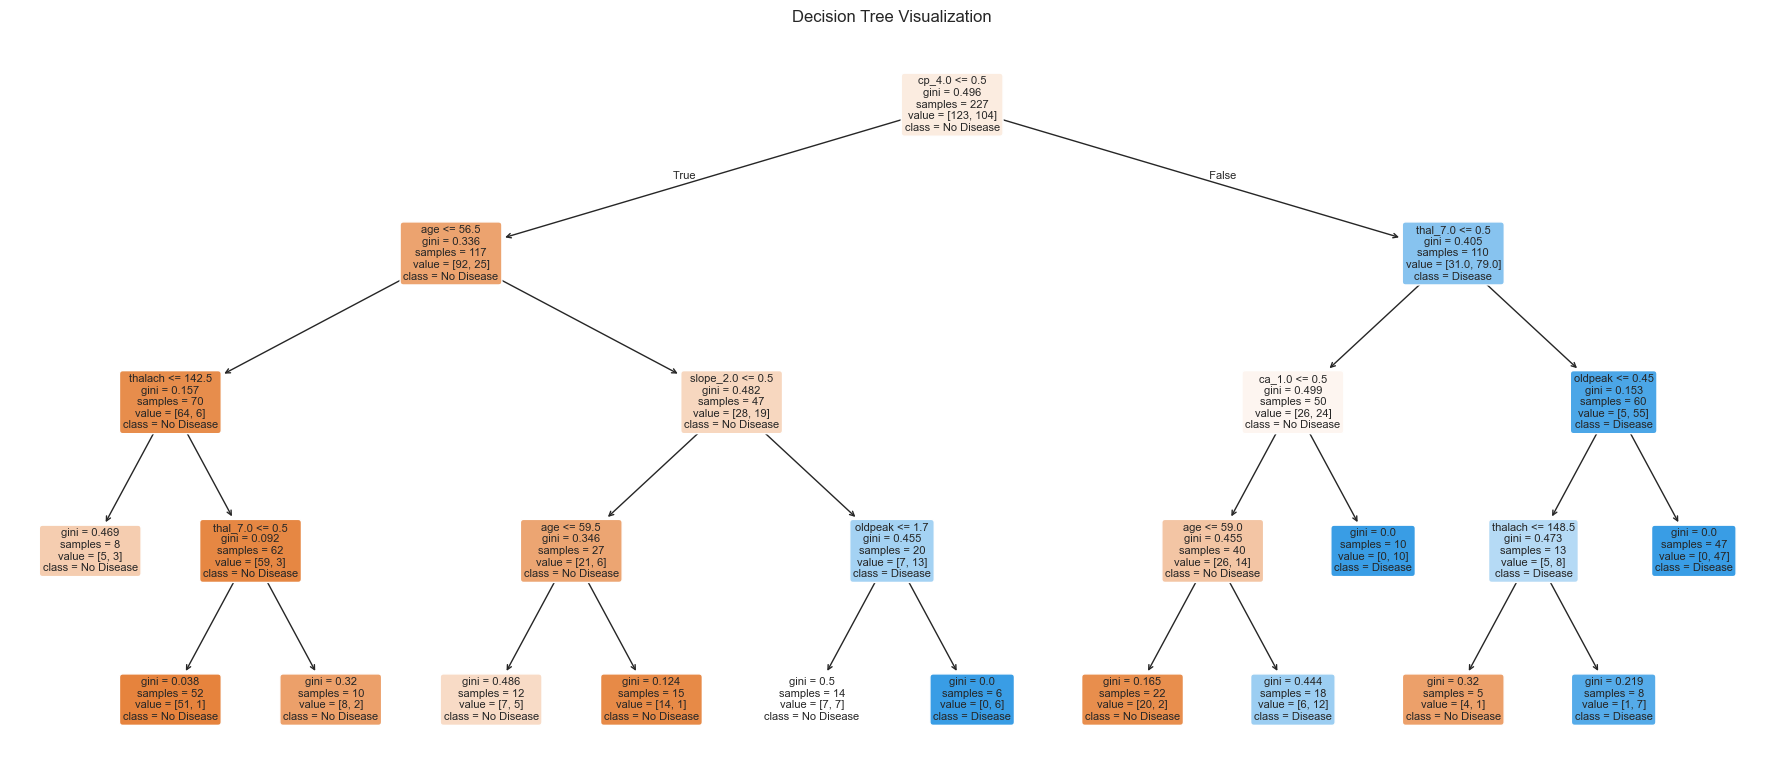

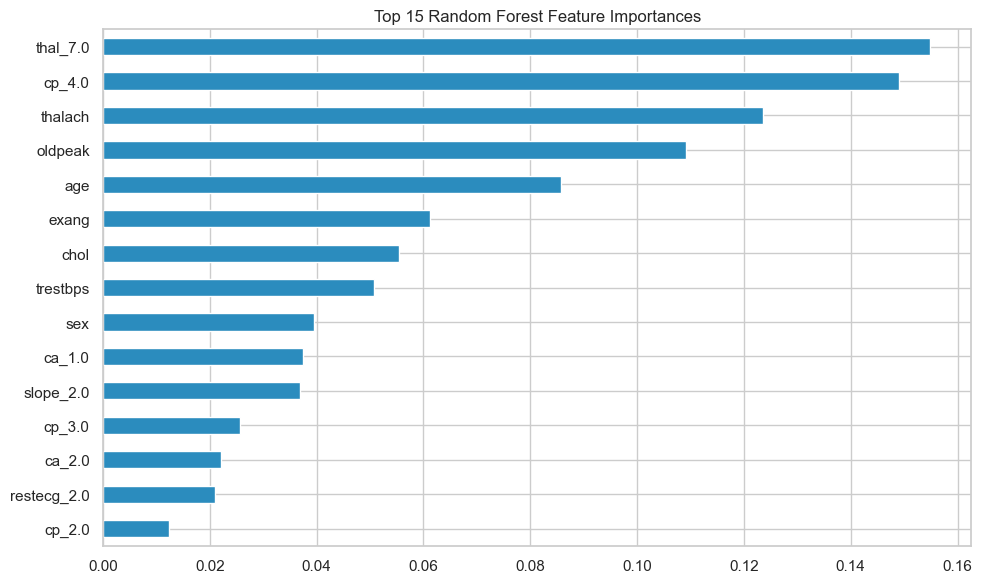

Recommended model (recall-priority): Random Forest


In [6]:
# Classification: Decision Tree vs Random Forest
X = work_df.drop(columns=["HeartDisease"]).copy()
y = work_df["HeartDisease"].copy()

cat_cols = [c for c in ["cp", "restecg", "slope", "thal", "ca"] if c in X.columns]
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Decision Tree
model_dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE)
model_dt.fit(X_train, y_train)
pred_dt = model_dt.predict(X_test)

# Random Forest
model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)

# Metrics
metrics = pd.DataFrame([
    {
        "model": "Decision Tree",
        "accuracy": accuracy_score(y_test, pred_dt),
        "precision": precision_score(y_test, pred_dt, zero_division=0),
        "recall": recall_score(y_test, pred_dt, zero_division=0),
        "f1": f1_score(y_test, pred_dt, zero_division=0),
    },
    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, pred_rf),
        "precision": precision_score(y_test, pred_rf, zero_division=0),
        "recall": recall_score(y_test, pred_rf, zero_division=0),
        "f1": f1_score(y_test, pred_rf, zero_division=0),
    },
]).sort_values("recall", ascending=False)

metrics.to_csv(out_dir / "model_metrics.csv", index=False)
display(metrics)

# Confusion matrices
for name, pred in [("decision_tree", pred_dt), ("random_forest", pred_rf)]:
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"{name.replace('_', ' ').title()} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(out_dir / f"{name}_confusion_matrix.png", dpi=150)
    plt.show()

# Decision Tree plot
plt.figure(figsize=(18, 8))
plot_tree(
    model_dt,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.savefig(out_dir / "decision_tree_plot.png", dpi=150)
plt.show()

# Feature importance (Random Forest)
fi = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fi.head(15).to_csv(out_dir / "feature_importance_top15.csv", header=["importance"])

plt.figure(figsize=(10, 6))
fi.head(15).sort_values().plot(kind="barh", color="#2b8cbe")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.savefig(out_dir / "feature_importance_top15.png", dpi=150)
plt.show()

# Text reports
(out_dir / "decision_tree_classification_report.txt").write_text(
    classification_report(y_test, pred_dt, digits=4),
    encoding="utf-8",
)
(out_dir / "random_forest_classification_report.txt").write_text(
    classification_report(y_test, pred_rf, digits=4),
    encoding="utf-8",
)

best_model = metrics.iloc[0]["model"]
print("Recommended model (recall-priority):", best_model)

In [7]:
# Quick checklist of generated deliverables
expected = [
    out_dir / "descriptive_statistics.csv",
    out_dir / "eda_target_distribution.png",
    out_dir / "eda_numeric_histograms.png",
    out_dir / "eda_correlation_heatmap.png",
    out_dir / "top_association_rules.csv",
    out_dir / "cluster_profiles.csv",
    out_dir / "cluster_distribution.png",
    out_dir / "cluster_pca_scatter.png",
    out_dir / "model_metrics.csv",
    out_dir / "decision_tree_confusion_matrix.png",
    out_dir / "random_forest_confusion_matrix.png",
    out_dir / "decision_tree_plot.png",
    out_dir / "feature_importance_top15.csv",
    out_dir / "feature_importance_top15.png",
    project_dir / "Case_Study_Report_Draft.md",
    project_dir / "Lastnames_CCS230_Finals.pdf",
]

for p in expected:
    print(("OK  " if p.exists() else "MISS"), p.name)

OK   descriptive_statistics.csv
OK   eda_target_distribution.png
OK   eda_numeric_histograms.png
OK   eda_correlation_heatmap.png
OK   top_association_rules.csv
OK   cluster_profiles.csv
OK   cluster_distribution.png
OK   cluster_pca_scatter.png
OK   model_metrics.csv
OK   decision_tree_confusion_matrix.png
OK   random_forest_confusion_matrix.png
OK   decision_tree_plot.png
OK   feature_importance_top15.csv
OK   feature_importance_top15.png
OK   Case_Study_Report_Draft.md
OK   Lastnames_CCS230_Finals.pdf
